# decision tree

This file experiments with decision trees to predict the targets: total area burned, average daily area burned, and duration.  This uses 5-fold CV to tune the decision tree.

✅ Data Loaded
  startdateseason       u10       v10        d2m        t2m         msl  \
0          Winter -3.701674  1.350839  278.64328  284.38715  102901.520   
1          Winter -4.775185  3.030015  287.59494  292.01648  102516.750   
2          Winter  0.070231  0.098946  287.74893  289.71127  102244.630   
3          Winter  1.650255  0.358445  278.82760  283.12076  102448.375   
4          Winter -2.200540  6.381189  292.18143  294.35640  101801.750   

           sp    lai_hv    lai_lv        tp         ssr  size (acres)  \
0  102447.460  2.988195  2.407728  0.000021   8017088.0   1218.229528   
1  102070.190  2.986613  2.406662  0.000020   5444096.0   1218.229528   
2  101797.350  2.983510  2.404584  0.003486   8655968.0   1218.229528   
3  101995.414  2.992889  2.410894  0.000000  12236688.0   1218.229528   
4  101360.100  2.985026  2.405601  0.025873   2535104.0   1218.229528   

   fire_spread (acres/day)  duration  
0               153.205336         8  
1               15

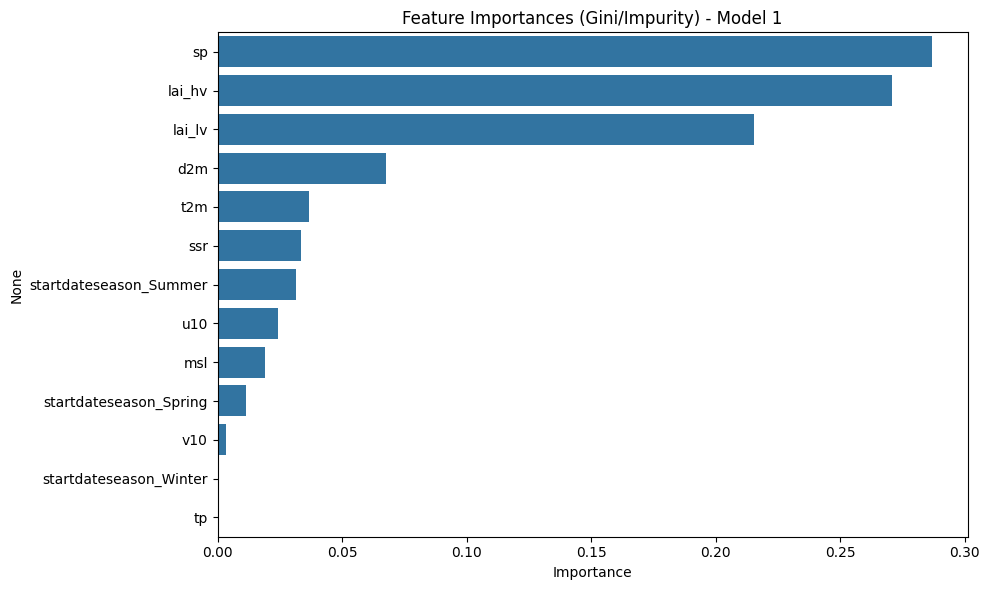

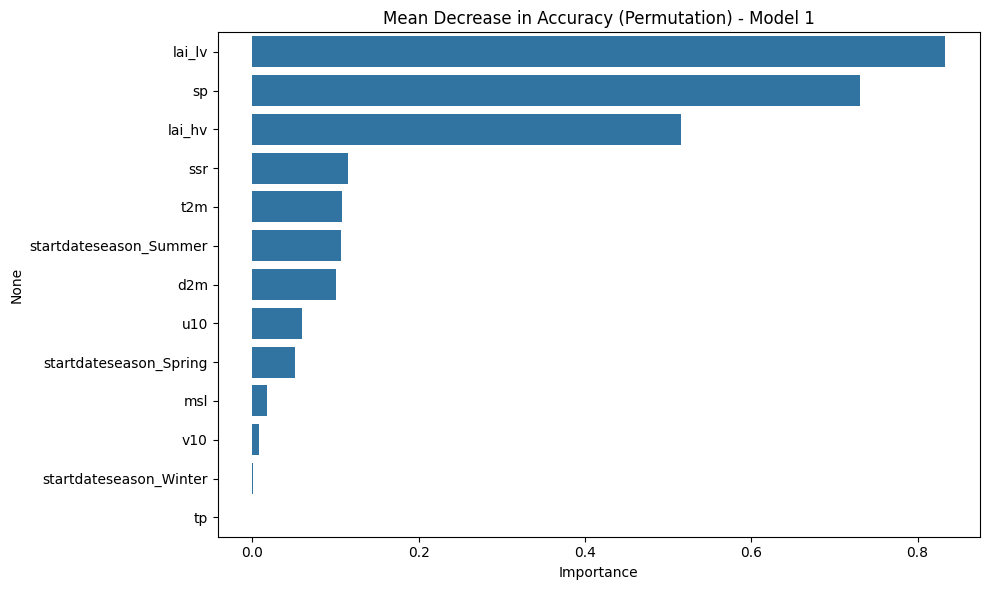


🌲 Model 2: Predicting fire_spread (acres/day)
📌 Best Hyperparameters: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
R² scores (per fold): [0.46424491 0.20219872 0.19531372 0.43559601 0.14505865]
✅ Mean R²: 0.2885
📉 MSE scores (per fold): [ 544640.00983765 1145894.74041155  490522.56078387  785068.97621582
  554120.23838793]
✅ Mean MSE: 704049.3051
✅ Mean RMSE: 827.8538


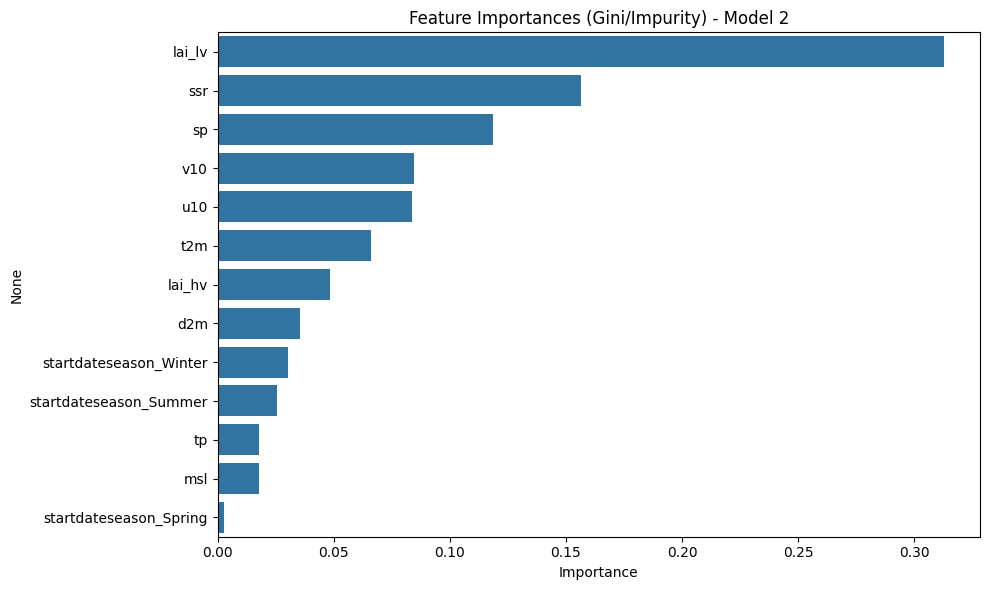

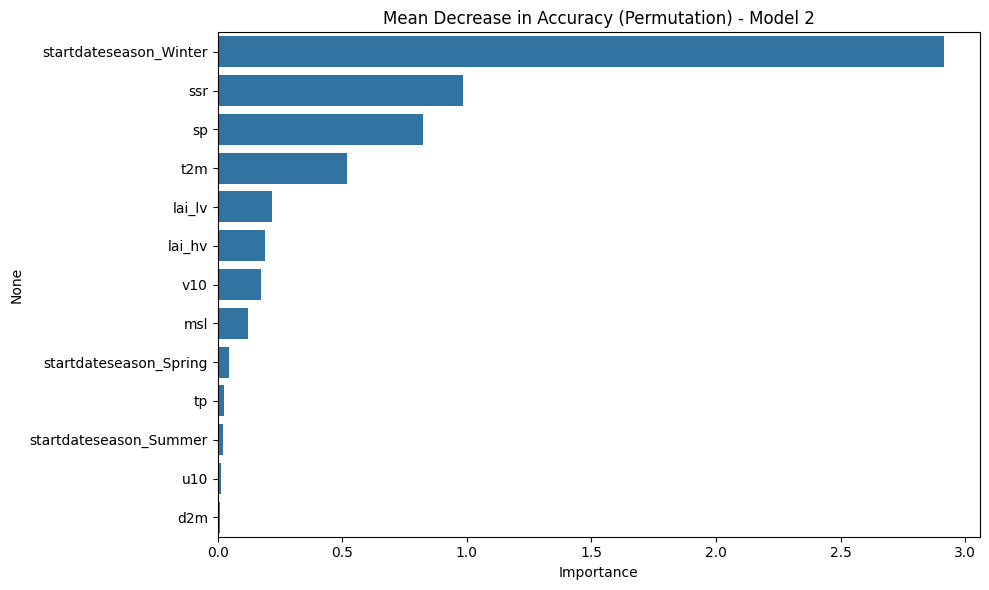


🌲 Model 3: Predicting duration
📌 Best Hyperparameters: {'criterion': 'friedman_mse', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}
R² scores (per fold): [0.33071176 0.28383397 0.36717137 0.30755288 0.35692533]
✅ Mean R²: 0.3292
📉 MSE scores (per fold): [22.52120073 24.52485645 21.26087518 23.88411411 22.05880811]
✅ Mean MSE: 22.8500
✅ Mean RMSE: 4.7785


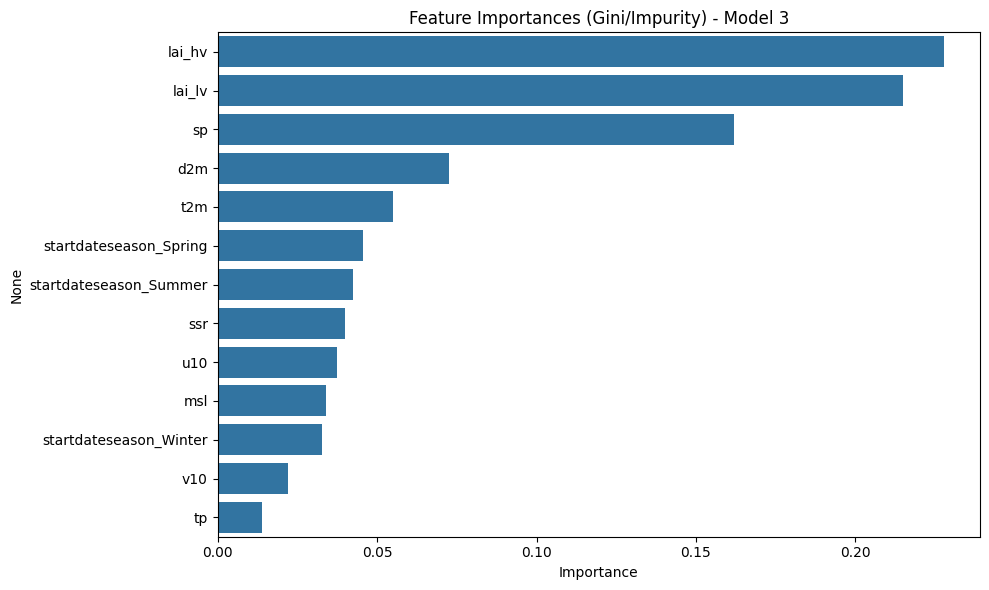

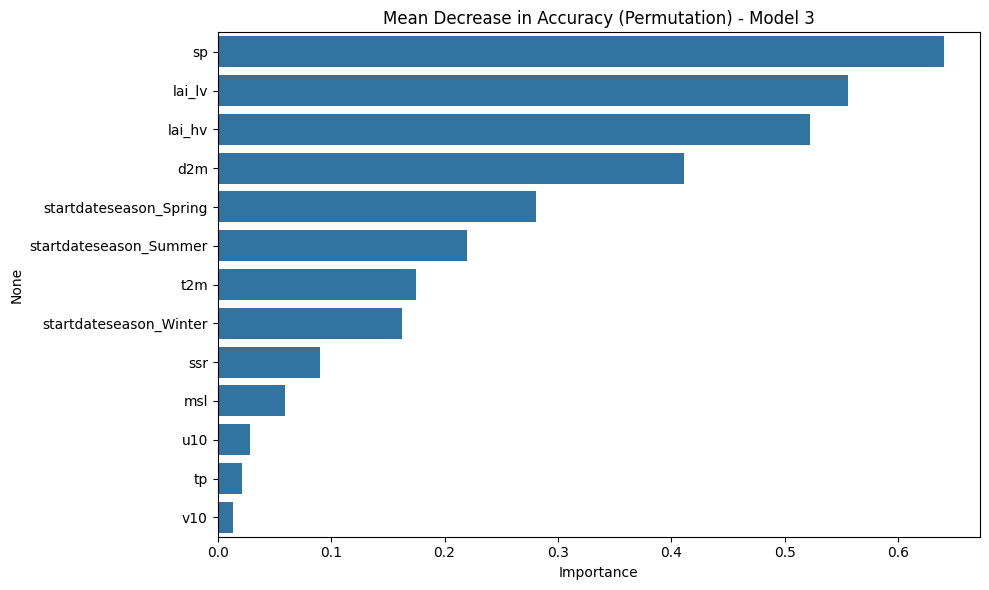

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.inspection import permutation_importance

# Load dataset
data = pd.read_excel("C:/Users/longl/Downloads/full_wildfire_weather_2020_2024.xlsx")
print("✅ Data Loaded")
print(data.head())

# Define predictors
predictors = ['u10', 'v10', 'd2m', 't2m', 'msl',
              'sp', 'lai_hv', 'lai_lv', 'tp', 'ssr', 'startdateseason']

# Split randomly into 80% train, 20% test
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Define CV and param grid
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error', 'friedman_mse']
}

# Helper function to plot feature importances
def plot_feature_importances(importances, feature_names, title):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

# --- Train and evaluate each model ---
def run_model(target, label):
    print(f"\n🌲 {label}: Predicting {target}")
    
    # Prepare features and target
    X_train = train_data[predictors]
    y_train = train_data[target]
    
    X_test = test_data[predictors]
    y_test = test_data[target]
    
    # Drop NAs
    X_train = X_train.dropna()
    y_train = y_train.loc[X_train.index]
    X_test = X_test.dropna()
    y_test = y_test.loc[X_test.index]

    # Encode season
    X_train = pd.get_dummies(X_train, columns=['startdateseason'], drop_first=True)
    X_test = pd.get_dummies(X_test, columns=['startdateseason'], drop_first=True)

    # Align columns (some categories might be missing)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Grid Search
    model = DecisionTreeRegressor(random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=kf,
                               scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Cross-validate best model
    neg_mse = cross_val_score(best_model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-neg_mse)
    r2_scores = cross_val_score(best_model, X_train, y_train, cv=kf, scoring='r2')

    # Output
    print("📌 Best Hyperparameters:", grid_search.best_params_)
    print(f"R² scores (per fold): {r2_scores}")
    print(f"✅ Mean R²: {r2_scores.mean():.4f}")
    print(f"📉 MSE scores (per fold): {-neg_mse}")
    print(f"✅ Mean MSE: {-neg_mse.mean():.4f}")
    print(f"✅ Mean RMSE: {rmse.mean():.4f}")

    # Plot built-in feature importances
    plot_feature_importances(best_model.feature_importances_,
                             X_train.columns,
                             f"Feature Importances (Gini/Impurity) - {label}")

    # Calculate and plot permutation importance (Mean Decrease in Accuracy)
    perm_result = permutation_importance(best_model, X_test, y_test, n_repeats=10,
                                         random_state=42, n_jobs=-1)
    plot_feature_importances(perm_result.importances_mean,
                             X_test.columns,
                             f"Mean Decrease in Accuracy (Permutation) - {label}")

# Run all three models
run_model(target='size (acres)', label='Model 1')
run_model(target='fire_spread (acres/day)', label='Model 2')
run_model(target='duration', label='Model 3')